In [81]:
# import basic libraries
import numpy as np
import pandas as pd
import scipy.io as io
from pathlib import Path
import scanpy as sc
import treedata as td
from fastrna.core import fastrna_hvg, fastrna_pca
import matplotlib.pyplot as plt

#### Data Loading

In [33]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*.h5td"): # Taking only the first replicate

    #tdatas[file_path.stem] = td.read_h5td(file_path)

    # For testing, extract only timepoint lower than E9.0
    # Extract stage from filename (e.g., "E8.5-R1" from "E8.5-R1-C1.h5td")
    stem = file_path.stem
    stage = stem.split("-")[0]  # Extract "E8.5", "E9.0", etc.
    
    # Parse the stage to compare versions (e.g., E8.5, E9.0)
    stage_num = float(stage[1:])  # Remove 'E' and convert to float
    
    # Exclude E8.5 and above
    if stage_num < 9:
        tdatas[stem] = td.read_h5td(file_path)

In [34]:
merged_tdata = td.concat(tdatas, merge= 'unique')

In [35]:
merged_tdata.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree
E8.5-R1-T2-AGCCTGACATAAGCTA-1,Midbrain,E8.5-R1-T2,E8.5-R1,E8.5,donor,38226.0,48.0,0.939394,0.424242,E8.5-R1-C1,G2/M,Midbrain,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T2-GCAGCCATCTGTAAGT-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,21301.0,6.0,0.878788,0.397849,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T2-TGATCCCCATGGTTAA-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,23958.0,8.0,0.969697,0.421569,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T1-CGTACAGCAACGTGCA-1,Telencephalon (dorsal),E8.5-R1-T1,E8.5-R1,E8.5,donor,48821.0,14.0,0.969697,0.431373,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
E8.5-R1-T2-ACGCGGTCAACCAACG-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,31433.0,17.0,0.939394,0.444444,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,28256.0,0.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN
E8.0-R1-T1-TGGTCCTCACTCGGAA-1,Gut,E8.0-R1-T1,E8.0-R1,E8.0,donor,10322.0,17.0,0.735294,NaN,NaN,G2/M,Gut,Endoderm,Endoderm,NaN
E8.0-R1-T1-TGTAGCGCAATCGAGT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,16391.0,0.0,NaN,NaN,NaN,G2/M,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN
E8.0-R1-T1-TGTCGATGTGCAATCT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,21732.0,1.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN


#### Extracting the gene expression Matrix

In [ ]:
gene_exp = merged_tdata.X.T

In [37]:
gene_exp.shape

(115820, 78258)

In [38]:
type(gene_exp)

scipy.sparse._csr.csr_matrix

#### Ordering the gene expression by batches 

In [39]:
batch_label = pd.factorize(merged_tdata.obs["embryo"])[0] # change the column name (Method) if required,
batch_label

array([0, 0, 0, ..., 8, 8, 8], shape=(115820,))

In [ ]:

# Step 3: Sort everything by batch label — required by FastRNA
idx_sort = batch_label.argsort()
batch_label_sort = batch_label[idx_sort]
gene_exp_sort = gene_exp[:, idx_sort]          # note: genes x cells, so sort columns


In [47]:
gene_exp_sort

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 712304436 stored elements and shape (78258, 115820)>

In [48]:

# Step 4: HVG selection
%time gene_vars = fastrna_hvg(gene_exp_sort, batch_label_sort)
gene_idx_var = gene_vars.argsort()[::-1]
gene_exp_hvg = gene_exp_sort[gene_idx_var[:3000], :]   # top 3000 HVGs
gene_exp_hvg.sort_indices()                         # required after gene selection


CPU times: user 5.31 s, sys: 1.01 s, total: 6.33 s
Wall time: 840 ms


In [56]:
gene_exp_hvg

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 112943057 stored elements and shape (3000, 115820)>

In [51]:

# Step 5: PCA
numi = np.asarray(gene_exp_sort.sum(axis=0)).ravel()   # size factors (total UMI per cell)
%time eig_val, eig_vec, pca, rrt = fastrna_pca(gene_exp_hvg, numi, batch_label_sort)


CPU times: user 3min 4s, sys: 2.71 s, total: 3min 7s
Wall time: 26.1 s


In [52]:
pca.shape, pca

((115820, 50),
 array([[ 1.7779647e+00, -1.3523176e+01,  6.0660706e+00, ...,
          4.5097513e+00,  2.6854706e-01, -1.2115258e+01],
        [ 4.3033543e+00, -1.7064560e+01,  1.0824074e+01, ...,
         -8.5974956e-01, -2.5791569e+00,  2.9432273e+00],
        [ 2.8412428e+00, -1.7806881e+01,  1.0465706e+01, ...,
          1.1369859e+00, -2.2249501e+00, -1.2131960e+01],
        ...,
        [ 2.4065149e-01, -2.1381793e+00,  5.9979405e+00, ...,
          5.3456049e+00,  1.8253336e+00, -1.9456048e+00],
        [ 4.1202867e-01, -2.4007635e+00,  8.4517984e+00, ...,
          4.5521717e+00, -7.2914553e-01, -2.6101036e+00],
        [-1.3315736e+01,  2.6860661e+01,  6.7643309e+00, ...,
          3.4831927e+00, -7.8355231e+00,  7.9970360e-03]],
       shape=(115820, 50), dtype=float32))

In [61]:

# Step 6: Put PCA back into adata in the original cell order
# idx_sort reordered cells, so we need to invert that permutation
idx_unsort = np.argsort(idx_sort)
merged_tdata
merged_tdata.obsm["X_pca"] = pca[idx_unsort, :]

In [72]:
# Store variance explained (eigenvalues) — scanpy expects ratio and ratio_cumsum
total_variance = eig_val.sum()
merged_tdata.uns["pca"] = {
    "variance": eig_val,
    "variance_ratio": eig_val / total_variance,
}

# Store gene loadings (eigenvectors) — shape should be (n_genes, n_pcs)
# eig_vec columns correspond to PCs, rows correspond to the selected HVGs
# Need to map back to full gene space
loadings_full = np.zeros((merged_tdata.n_vars, eig_vec.shape[1]))
loadings_full[gene_idx_var[:3000], :] = eig_vec
merged_tdata.varm["PCs"] = loadings_full

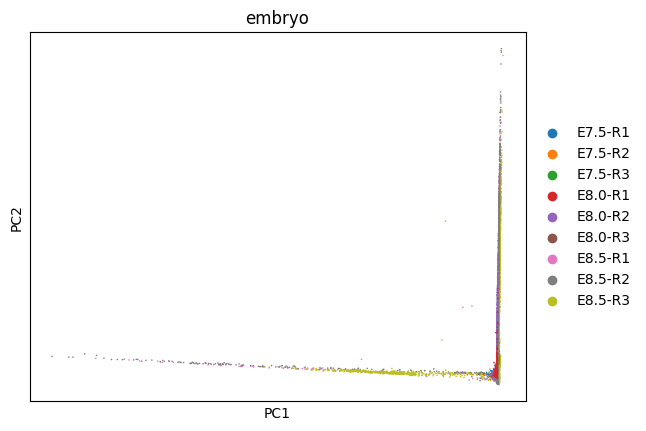

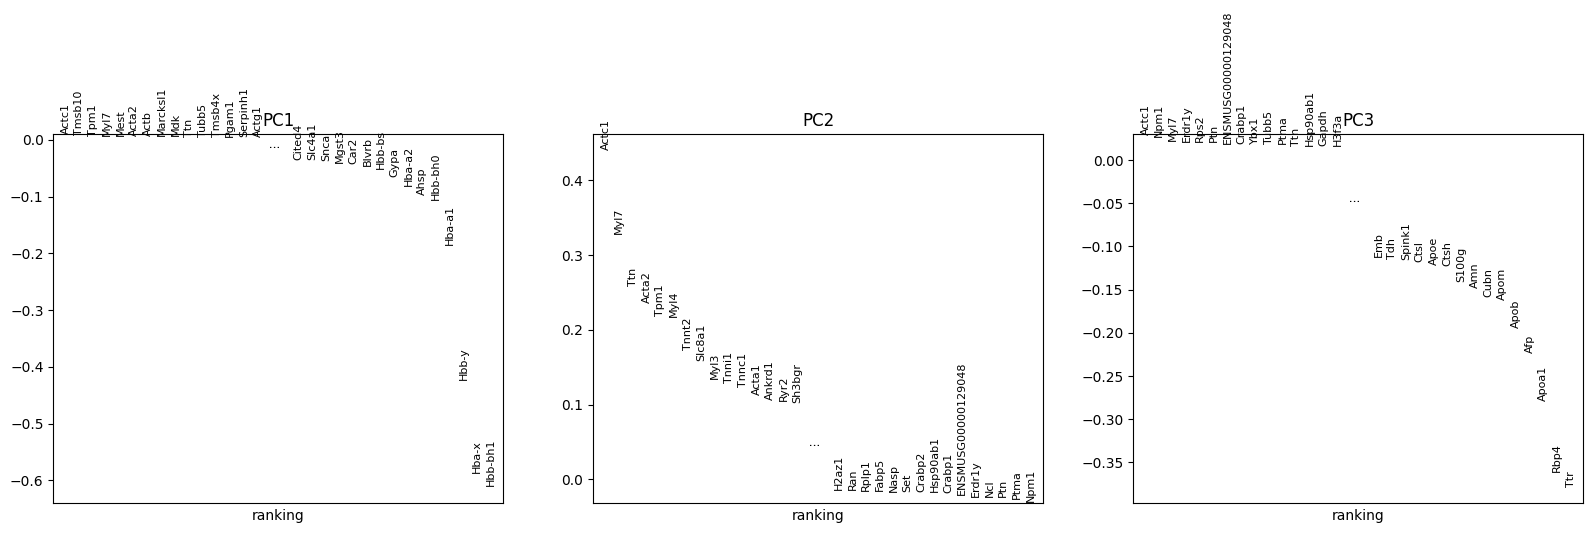

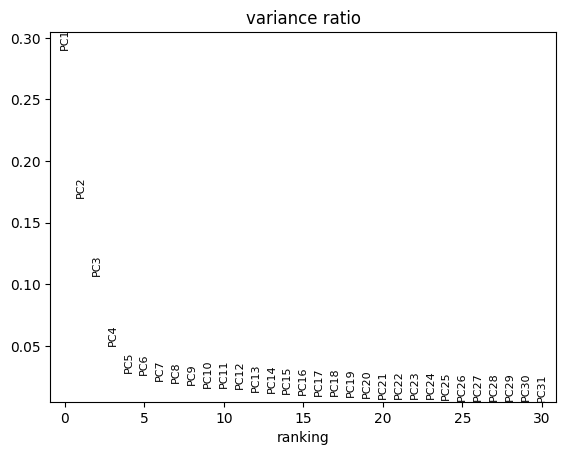

In [93]:
sc.pl.pca_overview(merged_tdata, color = 'embryo', size = 5)

In [75]:
sc.pp.neighbors(merged_tdata, n_pcs=10)

/project/imoskowitz/yubin/envs/Lineage_Tracing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sc.tl.umap(merged_tdata)


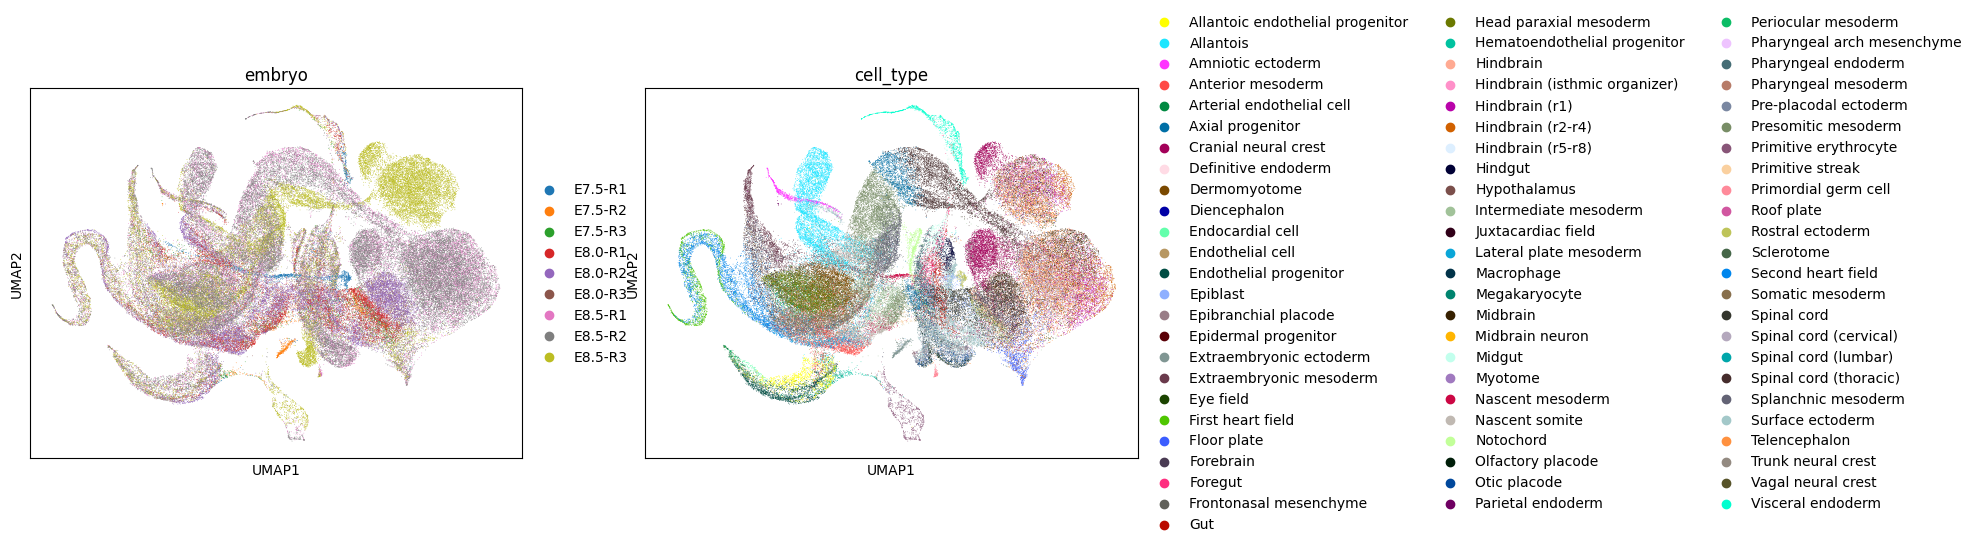

In [82]:
sc.pl.umap(merged_tdata, color = ['embryo','cell_type'])

In [86]:
merged_tdata.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree,highlight
E8.5-R1-T2-AGCCTGACATAAGCTA-1,Midbrain,E8.5-R1-T2,E8.5-R1,E8.5,donor,38226.0,48.0,0.939394,0.424242,E8.5-R1-C1,G2/M,Midbrain,Ectoderm,Neural ectoderm,E8.5-R1-C1,other
E8.5-R1-T2-GCAGCCATCTGTAAGT-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,21301.0,6.0,0.878788,0.397849,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,other
E8.5-R1-T2-TGATCCCCATGGTTAA-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,23958.0,8.0,0.969697,0.421569,E8.5-R1-C1,S,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,other
E8.5-R1-T1-CGTACAGCAACGTGCA-1,Telencephalon (dorsal),E8.5-R1-T1,E8.5-R1,E8.5,donor,48821.0,14.0,0.969697,0.431373,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,other
E8.5-R1-T2-ACGCGGTCAACCAACG-1,Telencephalon (dorsal),E8.5-R1-T2,E8.5-R1,E8.5,donor,31433.0,17.0,0.939394,0.444444,E8.5-R1-C1,G2/M,Telencephalon,Ectoderm,Neural ectoderm,E8.5-R1-C1,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,28256.0,0.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,other
E8.0-R1-T1-TGGTCCTCACTCGGAA-1,Gut,E8.0-R1-T1,E8.0-R1,E8.0,donor,10322.0,17.0,0.735294,NaN,NaN,G2/M,Gut,Endoderm,Endoderm,NaN,other
E8.0-R1-T1-TGTAGCGCAATCGAGT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,16391.0,0.0,NaN,NaN,NaN,G2/M,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,other
E8.0-R1-T1-TGTCGATGTGCAATCT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,21732.0,1.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,other


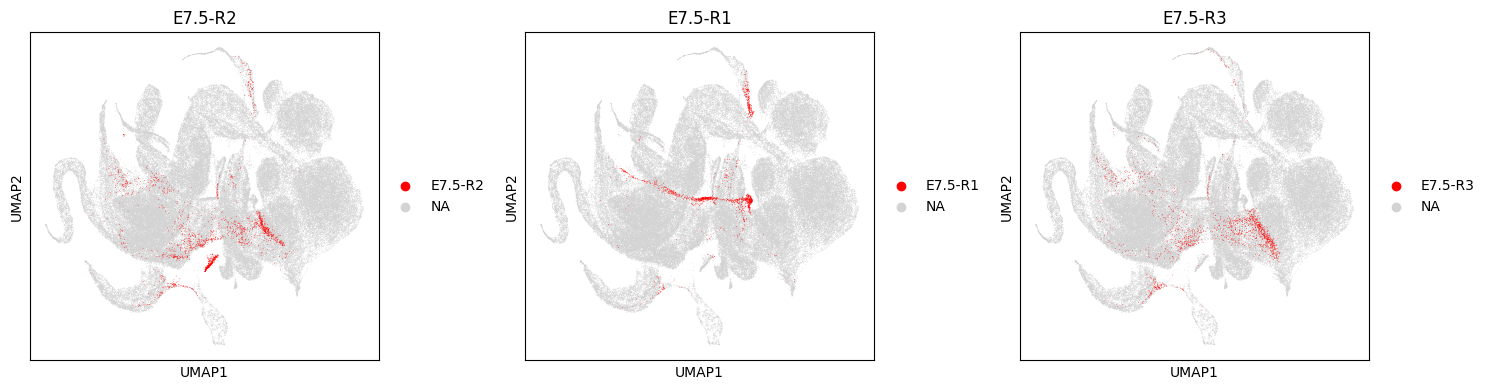

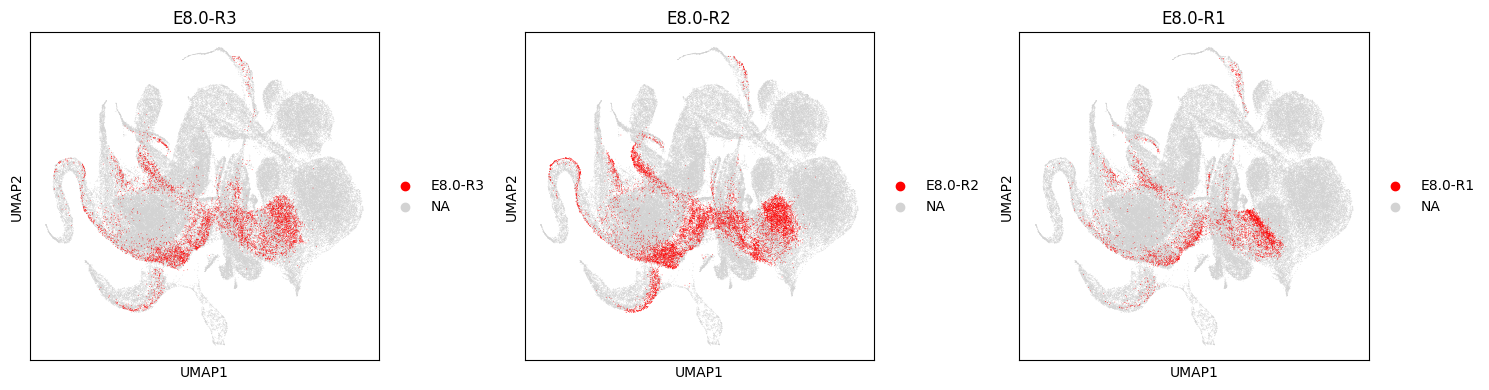

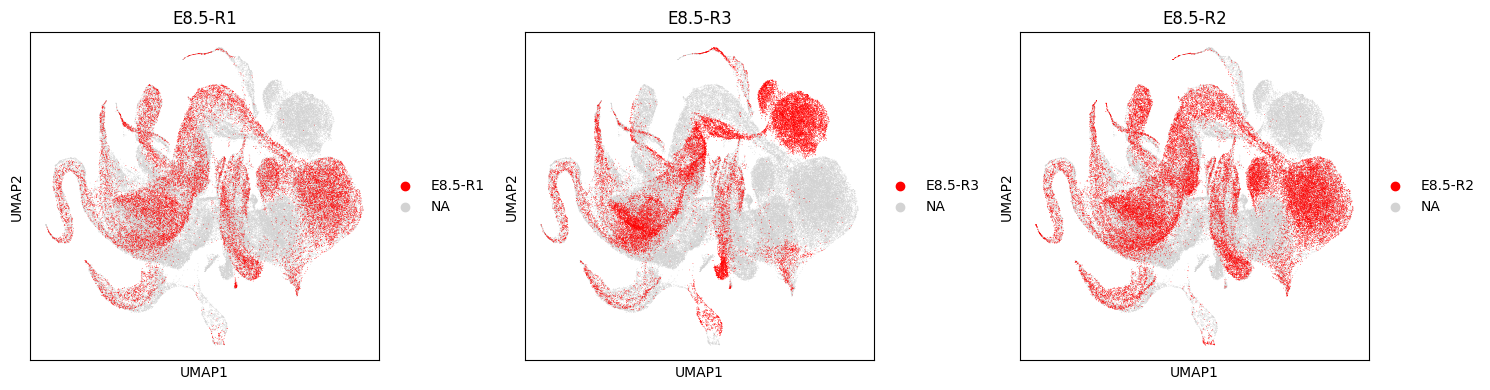

In [90]:
days = ["E7.5", "E8.0", "E8.5"]
for day in days:
    replicates = merged_tdata.obs.loc[merged_tdata.obs["stage"] == day, "embryo"].unique()

    fig, axes = plt.subplots(1, len(replicates), figsize=(5 * len(replicates), 4))

    for ax, rep in zip(axes, replicates):
        merged_tdata.obs["highlight"] = "other"
        merged_tdata.obs.loc[merged_tdata.obs["embryo"] == rep, "highlight"] = rep

        sc.pl.umap(
            merged_tdata,
            color="highlight",
            groups=[rep],
            na_color="lightgray",
            palette={rep: "red", 'other':'lightgray'},
            ax=ax,
            show=False,
            title=rep,
        )

    plt.tight_layout()
    plt.show()

Very bad batch effect. Although we haven't checked whether pearson fare any better